<!--
---
PURPOSE: Perform eye tracking QC and derive features.
REQUIRES:
  - outputs/reports/session_inventory.parquet
PRODUCES:
  - outputs/eye/session_{id}_eye_features.parquet
WHAT_NEXT: notebooks/05_Video_IO_and_Frame_Timebase.ipynb
---
-->

# 04 Eye Tracking QC and Features

**Purpose**
Perform eye tracking QC and derive features.

**Requires**
- `outputs/reports/session_inventory.parquet`

**Produces**
- `outputs/eye/session_{id}_eye_features.parquet`

**What to run next**
- `notebooks/05_Video_IO_and_Frame_Timebase.ipynb`

We load eye data (if present), run QC, and export features.


## Environment Setup
We add the repo `src/` to the Python path so notebooks can import shared modules.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
# Works whether JupyterLab is launched from repo root or from notebooks/
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
SRC  = ROOT / "src"

# put repo + src on sys.path
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if SRC.exists() and str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))


#print("ROOT:", ROOT)
#print("SRC :", SRC, "| exists:", SRC.exists())
#print("sys.path[0:3]:", sys.path[:3])

## Prerequisite Check
We parse the notebook header and validate required artifacts before running downstream steps.

In [2]:
from pathlib import Path
from reports import parse_notebook_header, validate_prerequisites

nb_path = ROOT / "notebooks" / "04_Eye_Tracking_QC_and_Features.ipynb"
header  = parse_notebook_header(nb_path)
missing = validate_prerequisites(header.get("REQUIRES", []))

if missing:
    print("Missing prerequisites:")
    for item in missing:
        print(" -", item)
else:
    print("All prerequisites satisfied.")

All prerequisites satisfied.


## Step 1: Load eye features
If eye tracking is missing, we record a flag and continue.

/opt/anaconda3/envs/vbn-analysis/lib/python3.10/site-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.6.0-alpha, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


1055240613 {'available': True, 'n_samples': 575523, 'missing_fraction': 0.03711059332120523}


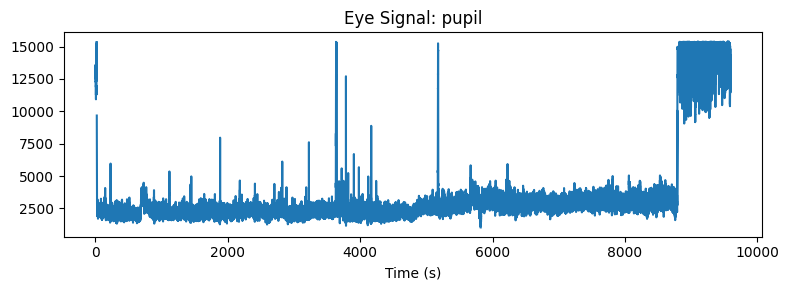

In [3]:
from io_sessions import load_sessions_csv, get_session_bundle
from qc import eye_qc_summary
from viz import plot_eye_qc

sessions = load_sessions_csv()
SESSION_IDS = [1055240613] 

for session_id in SESSION_IDS:
    bundle = get_session_bundle(session_id, sessions)
    eye = bundle.load_eye_features()
    print(session_id, eye_qc_summary(eye))
    plot_eye_qc(eye)